In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df= pd.read_csv('/content/drive/MyDrive/NTI/task/healthcare-dataset-stroke-data.csv')

In [4]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [7]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [8]:
df.drop(columns=['id'], inplace=True)

In [9]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)

/tmp/ipykernel_415/1439978410.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
numcol=['age','avg_glucose_level','bmi']
catcol=['gender','ever_married','work_type','Residence_type','smoking_status','heart_disease','stroke']

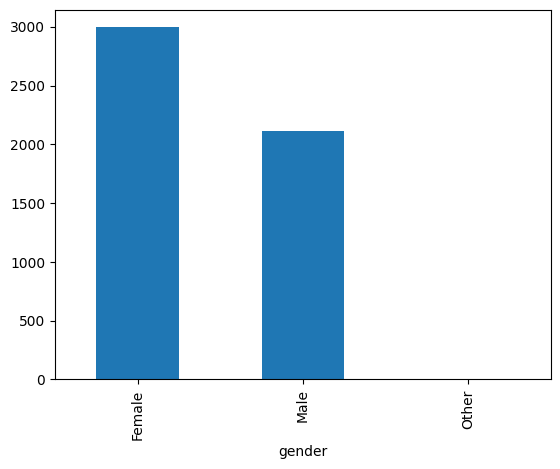

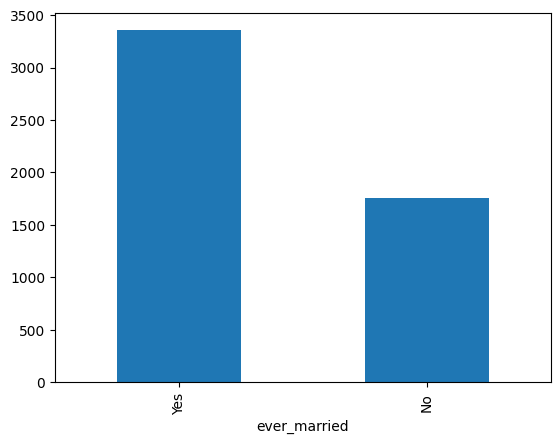

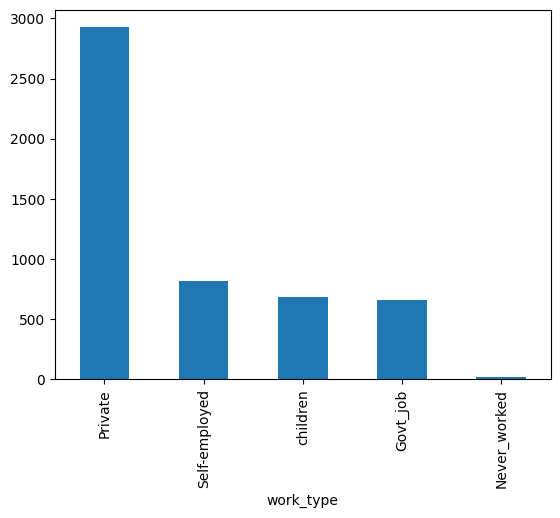

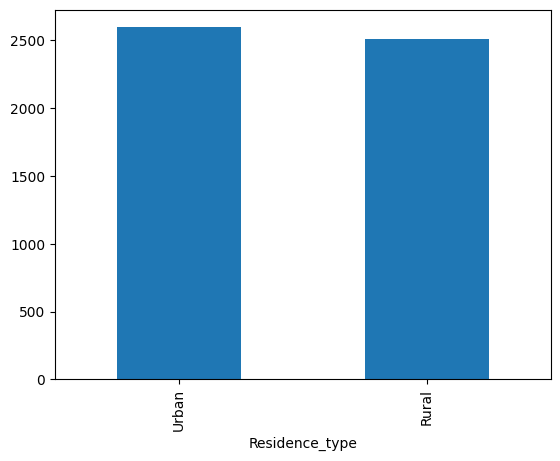

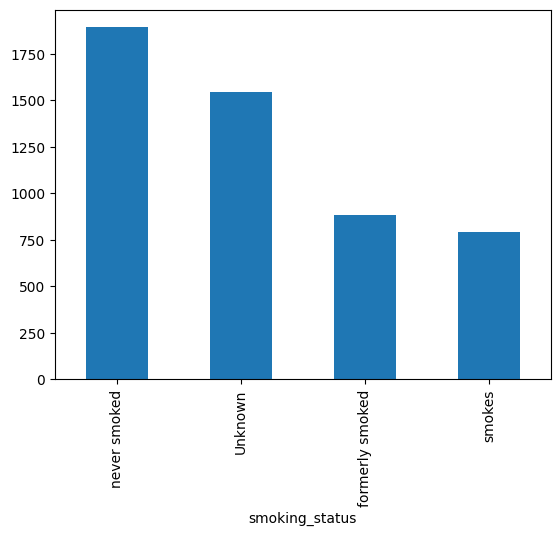

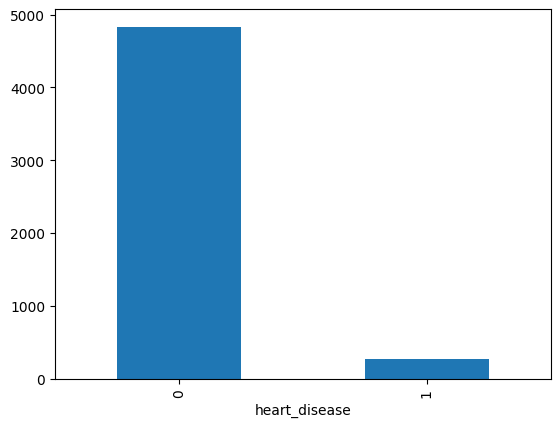

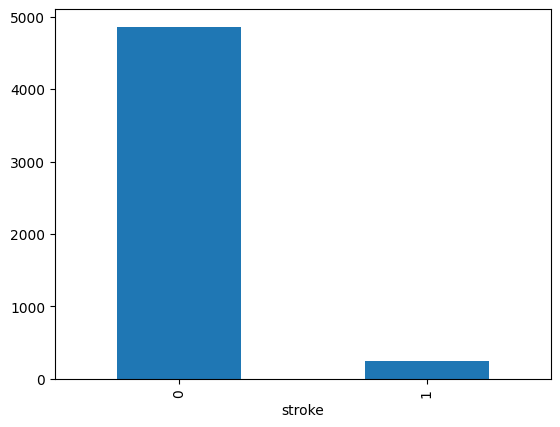

In [12]:
for col in catcol:
  df[col].value_counts().plot(kind='bar')
  plt.show()

In [13]:
df.drop(df[df['gender'] == 'Other'].index, inplace=True)

<Axes: >

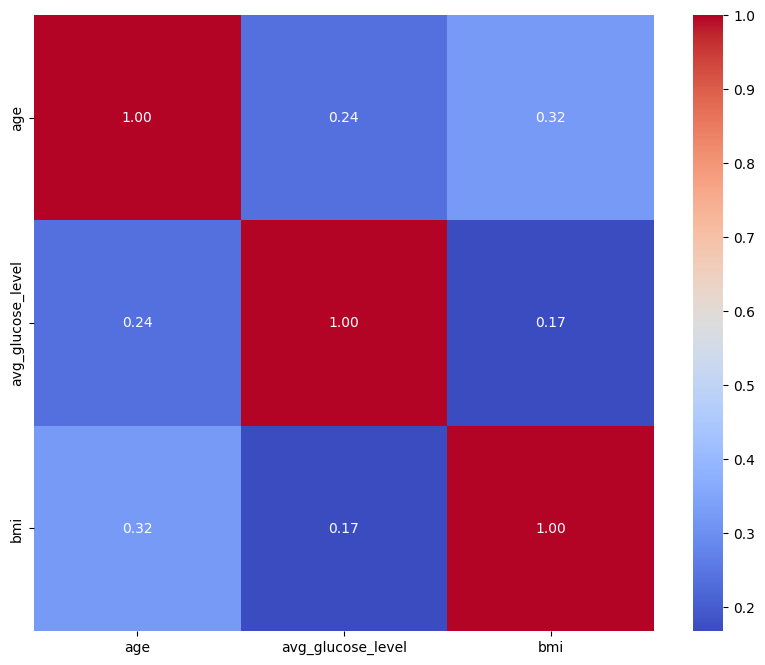

In [14]:
corr =df[numcol].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

In [15]:
df['gender'].value_counts()

,count
gender,
Female,2994
Male,2115


In [16]:
df.columns


Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

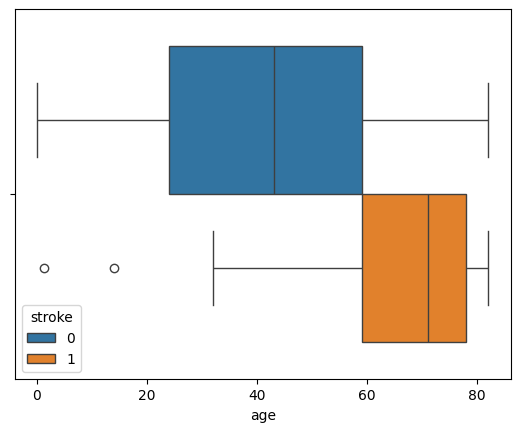

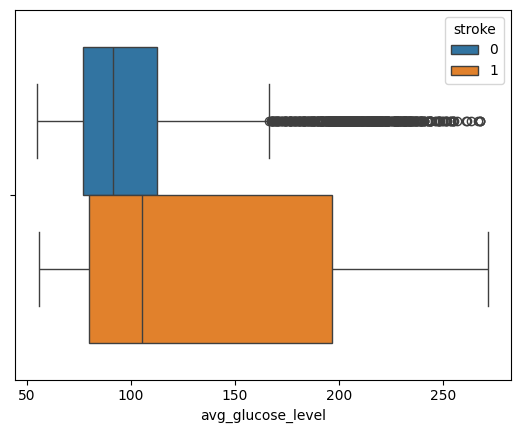

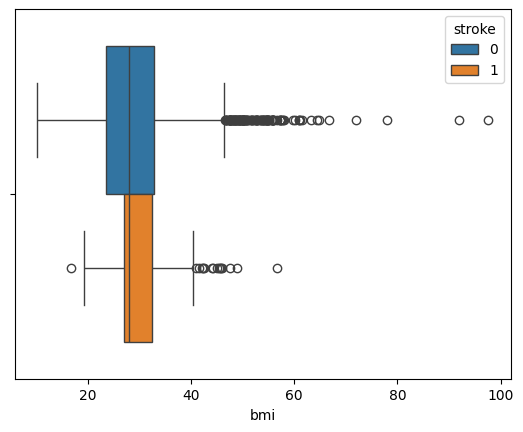

In [17]:

for col in numcol:
  sns.boxplot(data=df,x=col,hue="stroke")
  plt.show()

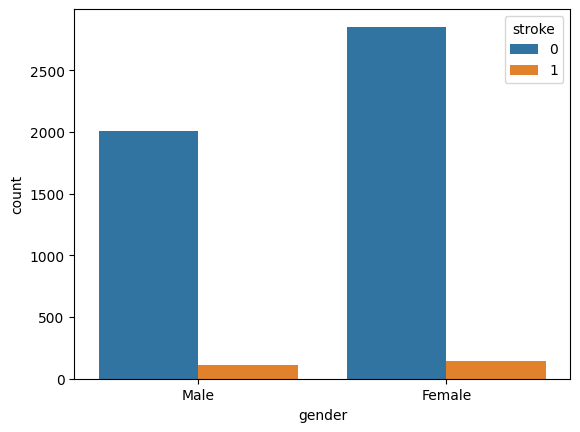

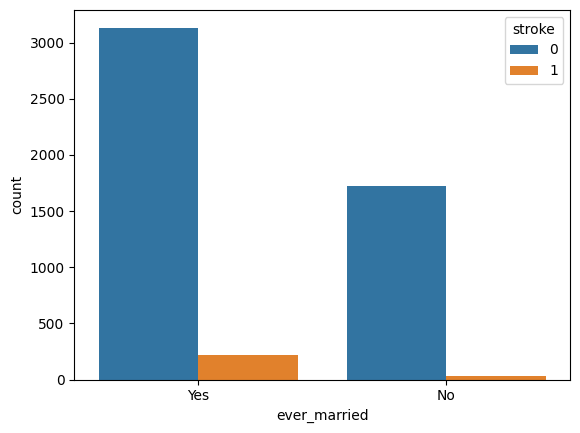

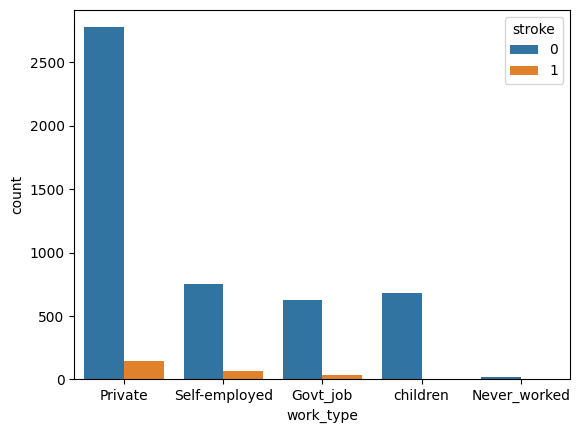

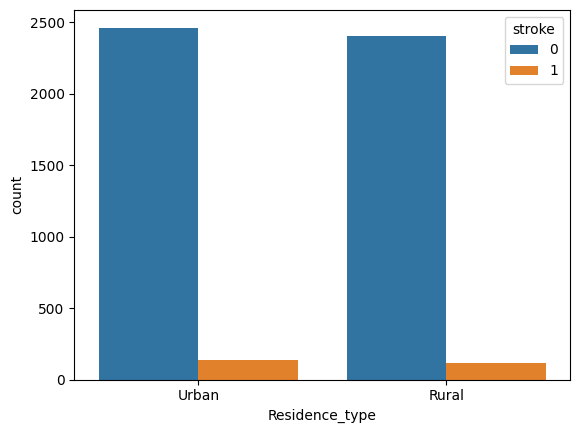

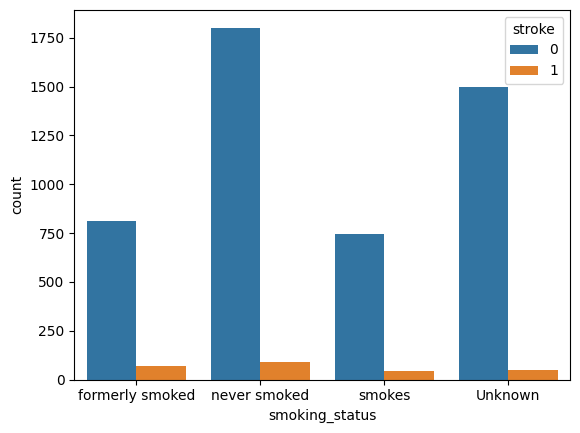

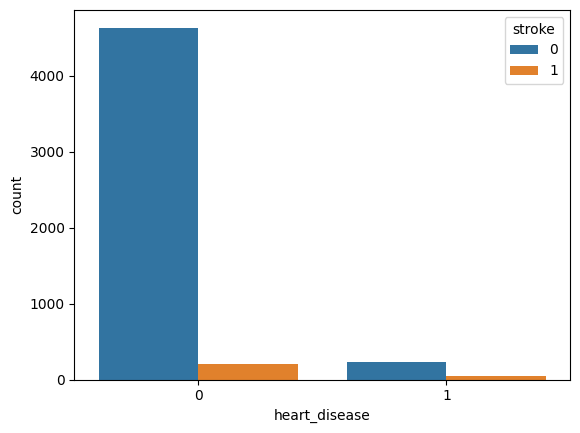

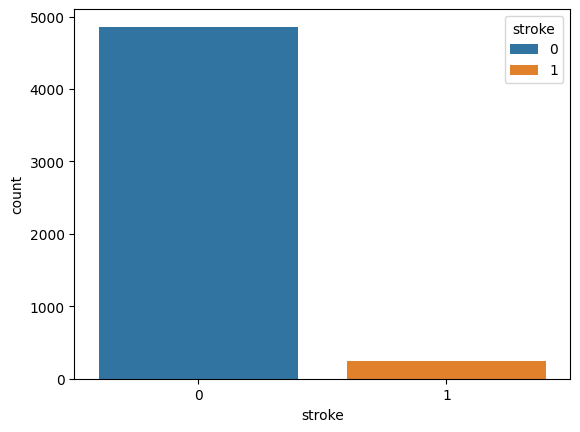

In [18]:
for col in catcol:
  sns.countplot(data=df,x=col,hue="stroke")
  plt.show()

In [19]:
# Anyone under a certain age is almost certainly a non-smoker
df.loc[(df['smoking_status'] == 'Unknown') & (df['age'] < 15), 'smoking_status'] = 'never smoked'
df[df['smoking_status'] == 'Unknown']['age'].describe()

,age
count,930.000000
mean,46.162366
std,19.804928
min,15.000000
25%,29.000000
50%,45.500000
75%,61.000000
max,82.000000


In [20]:
df['age_hypertension'] = df['age'] * df['hypertension']
df['age_heart_disease'] = df['age'] * df['heart_disease']
df['bmi_glucose_interaction'] = df['bmi'] * df['avg_glucose_level']
df['high_risk_elderly'] = ((df['age'] > 65) & ((df['hypertension'] == 1) | (df['heart_disease'] == 1))).astype(int)
df['risk_factor_count'] = df['hypertension'] + df['heart_disease'] + (df['age'] > 65).astype(int)

In [21]:
x = df.drop('stroke', axis=1)

y = df['stroke']

In [22]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (4087, 15)
Testing data: (1022, 15)


In [23]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke', 'age_hypertension', 'age_heart_disease',
       'bmi_glucose_interaction', 'high_risk_elderly', 'risk_factor_count'],
      dtype='object')

In [24]:
cat_feture=['gender',
 'ever_married',
 'work_type',
 'Residence_type',
 'smoking_status']

In [25]:

preprocessor = ColumnTransformer(
    transformers=[
        ('robust', StandardScaler(), numcol),
        ('onehot', OneHotEncoder(handle_unknown='ignore'),cat_feture)
    ],
    remainder='passthrough'
)

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [26]:
x_train_processed=pd.DataFrame(x_train_processed,columns=preprocessor.get_feature_names_out())
x_test_processed=pd.DataFrame(x_test_processed,columns=preprocessor.get_feature_names_out())

In [27]:
x_train_processed

,robust__age,robust__avg_glucose_level,robust__bmi,onehot__gender_Female,onehot__gender_Male,onehot__ever_married_No,onehot__ever_married_Yes,onehot__work_type_Govt_job,onehot__work_type_Never_worked,onehot__work_type_Private,...,onehot__smoking_status_formerly smoked,onehot__smoking_status_never smoked,onehot__smoking_status_smokes,remainder__hypertension,remainder__heart_disease,remainder__age_hypertension,remainder__age_heart_disease,remainder__bmi_glucose_interaction,remainder__high_risk_elderly,remainder__risk_factor_count
0,0.209397,-0.821221,0.549234,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2290.851,0.0,0.0
1,-0.629845,-0.485884,-0.988900,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1784.828,0.0,0.0
2,-0.364822,0.302317,-0.769166,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2734.260,0.0,0.0
3,-0.232310,0.062342,0.497532,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3553.836,0.0,0.0
4,-1.292405,-0.527297,0.355351,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2601.944,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4082,0.076885,-0.291800,0.807744,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3259.386,0.0,0.0
4083,-1.204064,0.169570,-1.208633,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2212.665,0.0,0.0
4084,0.783615,-0.609900,0.949924,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2847.130,0.0,0.0
4085,-0.541504,-0.712875,-0.368476,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1925.300,0.0,0.0


In [28]:
model= LogisticRegression()
model.fit(x_train_processed,y_train)
y_pred_train=model.predict(x_train_processed)
y_pred_test=model.predict(x_test_processed)

print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test))
print("Classification Report:\n", classification_report(y_test, y_pred_test))
print("R2 Score:", model.score(x_test_processed, y_test))

Training Accuracy: 0.9510643503792513
Testing Accuracy: 0.952054794520548
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

R2 Score: 0.952054794520548


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


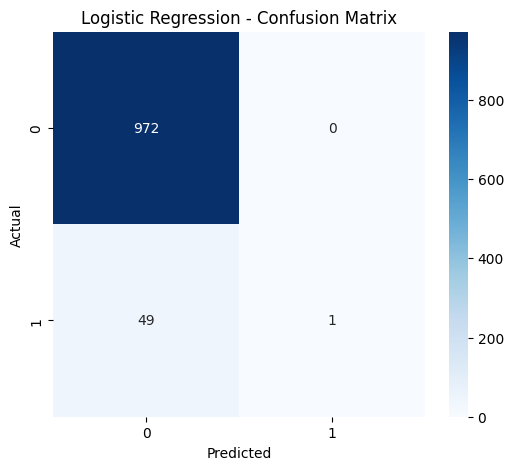

In [29]:
cm_logistic = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [30]:
model= LogisticRegression(class_weight='balanced')
model.fit(x_train_processed,y_train)
y_pred_train=model.predict(x_train_processed)
y_pred_test=model.predict(x_test_processed)

print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test))
print("Classification Report:\n", classification_report(y_test, y_pred_test))
print("R2 Score:", model.score(x_test_processed, y_test))

Training Accuracy: 0.7479814044531441
Testing Accuracy: 0.7465753424657534
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022

R2 Score: 0.7465753424657534


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


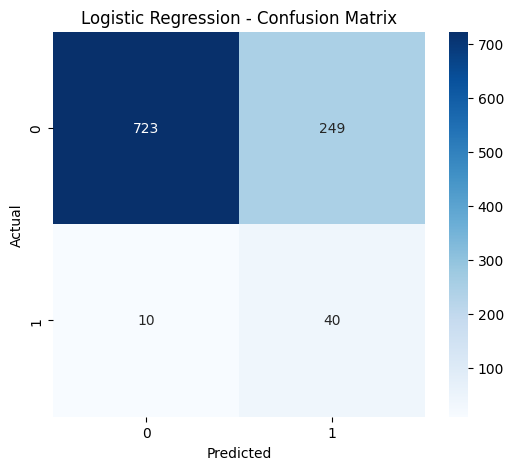

In [31]:
cm_logistic = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [32]:
model_svc2 = SVC(kernel='linear',C=1,class_weight='balanced')
model_svc2.fit(x_train_processed,y_train)
y_pred_train_svc2=model_svc2.predict(x_train_processed)
y_pred_test_svc2=model_svc2.predict(x_test_processed)

print("Training Accuracy:", accuracy_score(y_train, y_pred_train_svc2))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_svc2))
print("Classification Report:\n", classification_report(y_test, y_pred_test_svc2))
print("R2 Score:", model_svc2.score(x_test_processed, y_test))

Training Accuracy: 0.6667482260827012
Testing Accuracy: 0.6643835616438356
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.66      0.79       972
           1       0.11      0.84      0.20        50

    accuracy                           0.66      1022
   macro avg       0.55      0.75      0.49      1022
weighted avg       0.94      0.66      0.76      1022

R2 Score: 0.6643835616438356


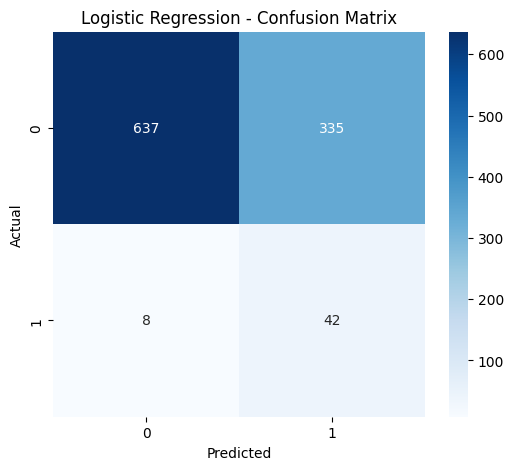

In [33]:
cm_logistic = confusion_matrix(y_test, y_pred_test_svc2)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [34]:
model_svc3 = SVC(kernel='poly',degree=4,C=1, gamma='scale',class_weight='balanced')
model_svc3.fit(x_train_processed,y_train)
y_pred_train_svc3=model_svc3.predict(x_train_processed)
y_pred_test_svc3=model_svc3.predict(x_test_processed)


print("Training Accuracy:", accuracy_score(y_train, y_pred_train_svc3))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_svc3))
print("Classification Report:\n", classification_report(y_test, y_pred_test_svc3))
print("R2 Score:", model_svc3.score(x_test_processed, y_test))

Training Accuracy: 0.9163200391485197
Testing Accuracy: 0.9148727984344422
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       972
           1       0.19      0.22      0.20        50

    accuracy                           0.91      1022
   macro avg       0.57      0.59      0.58      1022
weighted avg       0.92      0.91      0.92      1022

R2 Score: 0.9148727984344422


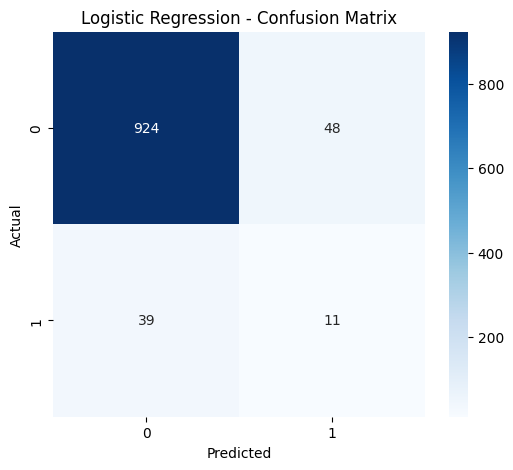

In [35]:
cm_logistic = confusion_matrix(y_test, y_pred_test_svc3)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


In [36]:
model_svc3 = SVC(kernel='rbf',C=1, gamma='auto',class_weight='balanced')
model_svc3.fit(x_train_processed,y_train)
y_pred_train_svc3=model_svc3.predict(x_train_processed)
y_pred_test_svc3=model_svc3.predict(x_test_processed)


print("Training Accuracy:", accuracy_score(y_train, y_pred_train_svc3))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_svc3))
print("Classification Report:\n", classification_report(y_test, y_pred_test_svc3))
print("R2 Score:", model_svc3.score(x_test_processed, y_test))

Training Accuracy: 0.9811597748960117
Testing Accuracy: 0.9256360078277887
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       972
           1       0.07      0.04      0.05        50

    accuracy                           0.93      1022
   macro avg       0.51      0.51      0.51      1022
weighted avg       0.91      0.93      0.92      1022

R2 Score: 0.9256360078277887


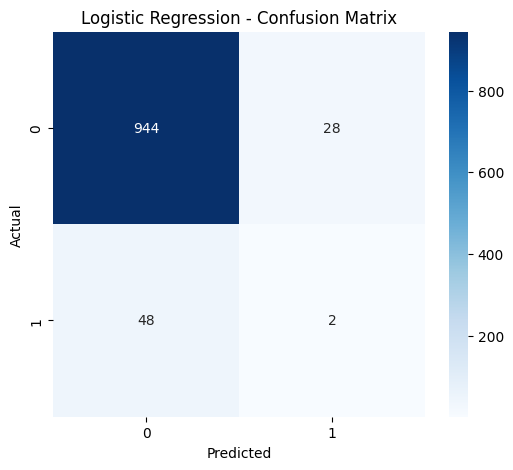

In [37]:
cm_logistic = confusion_matrix(y_test, y_pred_test_svc3)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


In [38]:
model_svc2 = SVC(kernel='linear',C=10,class_weight='balanced')
model_svc2.fit(x_train_processed,y_train)
y_pred_train_svc2=model_svc2.predict(x_train_processed)
y_pred_test_svc2=model_svc2.predict(x_test_processed)

print("Training Accuracy:", accuracy_score(y_train, y_pred_train_svc2))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_svc2))
print("Classification Report:\n", classification_report(y_test, y_pred_test_svc2))
print("R2 Score:", model_svc2.score(x_test_processed, y_test))

Training Accuracy: 0.6665035478345975
Testing Accuracy: 0.6673189823874756
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.66      0.79       972
           1       0.11      0.82      0.19        50

    accuracy                           0.67      1022
   macro avg       0.55      0.74      0.49      1022
weighted avg       0.94      0.67      0.76      1022

R2 Score: 0.6673189823874756


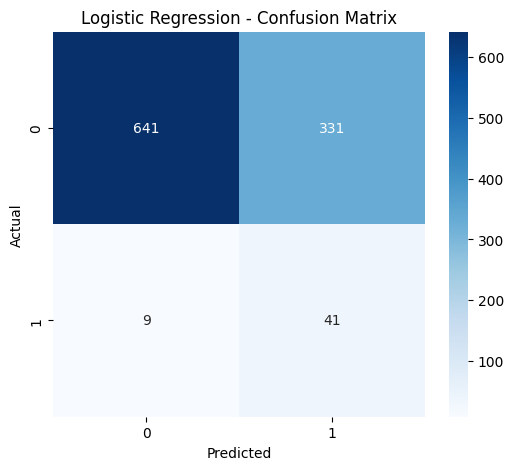

In [39]:
cm_logistic = confusion_matrix(y_test, y_pred_test_svc2)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


In [40]:
model_svc = SVC(kernel='linear',C=1,class_weight='balanced')
model_svc.fit(x_train_processed,y_train)
y_pred_train_svc =model_svc.predict(x_train_processed)
y_pred_test_svc =model_svc.predict(x_test_processed)

print("Training Accuracy:", accuracy_score(y_train, y_pred_train_svc))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_svc))
print("Classification Report:\n", classification_report(y_test, y_pred_test_svc))
print("R2 Score:", model.score(x_test_processed, y_test))

Training Accuracy: 0.6667482260827012
Testing Accuracy: 0.6643835616438356
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.66      0.79       972
           1       0.11      0.84      0.20        50

    accuracy                           0.66      1022
   macro avg       0.55      0.75      0.49      1022
weighted avg       0.94      0.66      0.76      1022

R2 Score: 0.7465753424657534


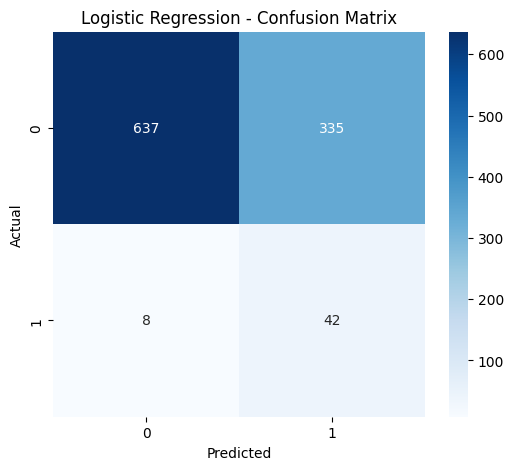

In [41]:
cm_logistic = confusion_matrix(y_test, y_pred_test_svc)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


In [42]:
model_svc3 = SVC(kernel='sigmoid',C=1, gamma='auto',class_weight='balanced')
model_svc3.fit(x_train_processed,y_train)
y_pred_train_svc3=model_svc3.predict(x_train_processed)
y_pred_test_svc3=model_svc3.predict(x_test_processed)


print("Training Accuracy:", accuracy_score(y_train, y_pred_train_svc3))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_svc3))
print("Classification Report:\n", classification_report(y_test, y_pred_test_svc3))
print("R2 Score:", model_svc3.score(x_test_processed, y_test))

Training Accuracy: 0.951309028627355
Testing Accuracy: 0.9510763209393346
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

R2 Score: 0.9510763209393346


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


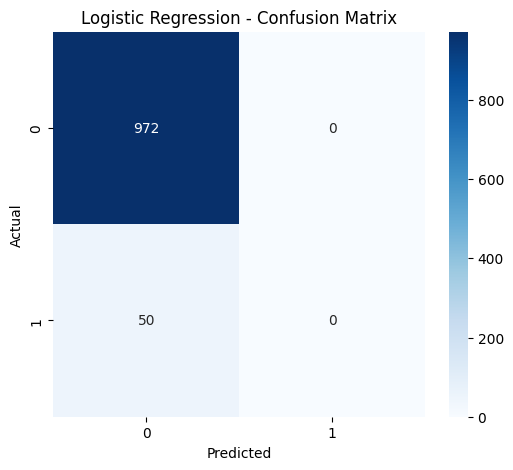

In [43]:
cm_logistic = confusion_matrix(y_test, y_pred_test_svc3)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()